# 05 — Client signups per month with running total

Monthly new-client signups (`role_id = 6`), with a cumulative running total and month-over-month growth %, using a CTE plus `SUM() OVER()` / `LAG()` window functions. Mirrors `docs/Client_Querires.md` §1.2.

In [ ]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
import pandas as pd

load_dotenv()

engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASS')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

In [2]:
query = """
WITH monthly_signups AS (
  SELECT
    DATE_FORMAT(created_at, '%Y-%m-01') AS signup_month,
    COUNT(*) AS new_clients
  FROM users
  WHERE role_id = 6
  GROUP BY signup_month
)
SELECT
  signup_month,
  new_clients,
  SUM(new_clients) OVER (ORDER BY signup_month) AS cumulative_clients,
  ROUND(
    100 * (new_clients - LAG(new_clients) OVER (ORDER BY signup_month))
    / NULLIF(LAG(new_clients) OVER (ORDER BY signup_month), 0),
    1
  ) AS mom_growth_pct
FROM monthly_signups
ORDER BY signup_month;
"""

# text() routes this through SQLAlchemy's compiler instead of PyMySQL's raw
# `%`-mogrify, which otherwise chokes on the literal `%Y`/`%m` in DATE_FORMAT.
df = pd.read_sql(text(query), engine, parse_dates=["signup_month"])
print(df)

  signup_month  new_clients  cumulative_clients  mom_growth_pct
0   2026-01-01           86                86.0             NaN
1   2026-02-01            2                88.0           -97.7
2   2026-03-01           10                98.0           400.0
3   2026-04-01            6               104.0           -40.0
4   2026-05-01           16               120.0           166.7
5   2026-06-01            3               123.0           -81.3
6   2026-07-01            2               125.0           -33.3


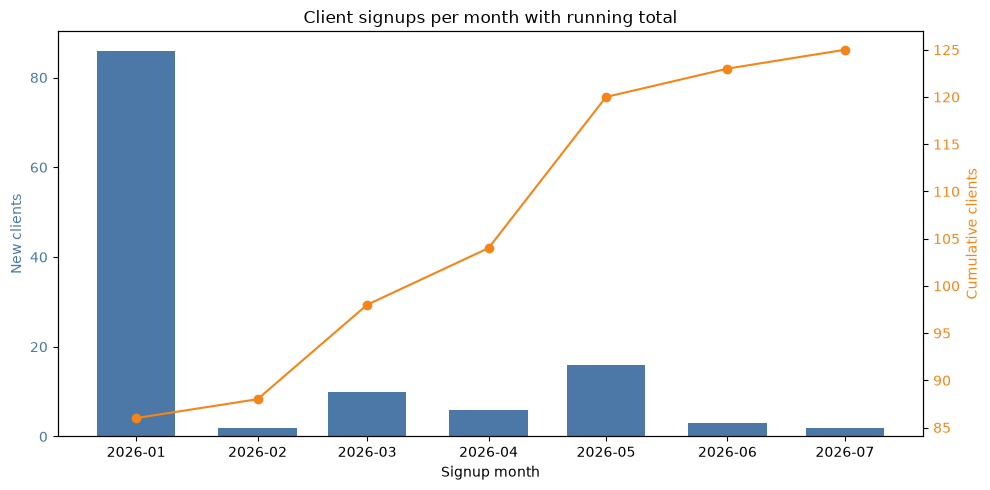

In [3]:
%matplotlib inline
import os
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(df["signup_month"], df["new_clients"], width=20, color="#4C78A8", label="New clients")
ax1.set_xlabel("Signup month")
ax1.set_ylabel("New clients", color="#4C78A8")
ax1.tick_params(axis="y", labelcolor="#4C78A8")

ax2 = ax1.twinx()
ax2.plot(df["signup_month"], df["cumulative_clients"], color="#F58518", marker="o", label="Cumulative clients")
ax2.set_ylabel("Cumulative clients", color="#F58518")
ax2.tick_params(axis="y", labelcolor="#F58518")

plt.title("Client signups per month with running total")
fig.tight_layout()

os.makedirs("../assets/img", exist_ok=True)
fig.savefig("../assets/img/client_signups_running_total.png", dpi=150)
plt.show()